# HKAN intermediate stages - TF1 to TF5

In [1]:
import numpy as np
import evaluation_metrics as em
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

from hkan.hkan import (
    ExpandingLayer, ConnectingLayer,
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    set_tqdm_disable,
)

set_tqdm_disable(True)
plt.rcParams['mathtext.fontset'] = 'cm'

DATA_DIR = "data"


In [2]:
def hkan_layer_step(
        X, y, n_vars_out,
        n_basis=15, centers="random_data_points", basis_fn=Sigmoid(s=8),
        sigmas="none", fixed_sigma=1, expanding_base_regressor=None, connecting_base_regressor=None):
    """
    Run ONE HKAN layer: ExpandingLayer (-> phi) then ConnectingLayer (-> h).

    Parameters
    ----------
    X : input to this layer (raw x for layer 1, or previous layer's h for later layers)
    y : target
    n_vars_out : number of output nodes for this layer (use 1 for the final layer)
    n_basis, centers, basis_fn : passed straight to ExpandingLayer
    expanding_base_regressor, connecting_base_regressor : override the default
        LinearRegression, e.g. Ridge(alpha=0.1), for either sub-step

    Returns
    -------
    phi : ndarray (n_vars_out, n_vars_in, n_samples) -- block functions (BlFs)
    h   : ndarray (n_samples, n_vars_out) -- this layer's h-function output,
          ready to feed as `X` into the next call
    expand, connect : the fitted layer objects (kept in case you want to
          later `.transform()`/`.predict()` this same fitted layer on new
          data, e.g. a clean grid for plot_surface)
    """
    # expand each input variable into weighted basis-function combinations (BlFs)
    expand = ExpandingLayer(
        n_vars_out=n_vars_out, n_basis=n_basis, centers=centers, basis_fn=basis_fn,
        sigmas=sigmas, fixed_sigma=fixed_sigma, base_regressor=expanding_base_regressor,
    )
    expand.fit(X, y)
    phi = expand.transform(X)

    # linearly combine BlFs across inputs into this layer's h-function(s)
    connect = ConnectingLayer(base_regressor=connecting_base_regressor)
    connect.fit(phi, y)

    # single-output (final) layer uses predict(); multi-output layers use transform()
    if n_vars_out > 1:
        h = connect.transform(phi)          # shape (n_samples, n_vars_out)
    else:
        h = connect.predict(phi).reshape(-1, 1)  # keep 2D for consistency, shape (n_samples, 1)

    return phi, h, expand, connect


In [3]:
def build_hkan_stack(X_train, y_train, layer_configs):
    """
    Chain multiple hkan_layer_step() calls to build an L-layer HKAN.

    Parameters
    ----------
    X_train, y_train : training data
    layer_configs : list of dicts, one per layer, each passed as **kwargs
        to hkan_layer_step (e.g. n_vars_out, n_basis, centers, basis_fn, ...).
        The LAST config should have n_vars_out=1.

    Returns
    -------
    stages : list of (layer_idx, phi, h) for every layer, ready for plot_hkan_stages_dynamic
    yhat   : ndarray (n_samples,) -- final layer's h, flattened to 1D (the model's prediction)
    """
    X_current = X_train
    stages = []

    # feed each layer's h-function output as the next layer's input
    for i, cfg in enumerate(layer_configs, start=1):
        phi, h, expand, connect = hkan_layer_step(X_current, y_train, **cfg)
        stages.append((i, phi, h))
        X_current = h   # next layer's input is this layer's output

    yhat = stages[-1][2].ravel()   # final layer's h, flattened to 1D
    return stages, yhat


In [4]:
def plot_hkan_stages_dynamic(X_train, y_train, stages, block_idx="random", cmap="inferno",
                              seed=None, feature_idx=(0, 1)):
    """
    stages: list of (layer_idx, phi, h) as produced by build_hkan_stack.
    block_idx: which (q, p) block to show for each layer's phi, or "random".
    feature_idx: which two columns of X_train to use as the x1/x2 axes in the
        3D surface plots. only matters for datasets with more than 2 inputs (TF4).
    """
    f1, f2 = feature_idx
    x1, x2 = X_train[:, f1], X_train[:, f2]
    plot_items = []
    rng = np.random.default_rng(seed)

    # build one (phi-block, h-node) entry pair per layer
    for layer_idx, phi, h in stages:
        n_vars_out = phi.shape[0]
        n_vars_in = phi.shape[1]

        # pick which (q, p) block to display for this layer
        if block_idx == "random":
            qq = rng.integers(0, n_vars_out)
            pp = rng.integers(0, n_vars_in)
        else:
            q, p = block_idx # set (q, p)
            qq, pp = min(q, n_vars_out - 1), min(p, n_vars_in - 1)

        plot_items.append(
            (rf"$\phi^{{({layer_idx})}}_{{q_{{{qq}}},p_{{{pp}}}}}$", phi[qq, pp, :],
             f"Layer {layer_idx} BlF (q={qq}, p={pp})", cmap)
        )
        plot_items.append(
            (rf"$h^{{({layer_idx})}}_{{q_{{{qq}}}}}$", h[:, qq],
             f"Layer {layer_idx} h-function (q={qq})", cmap)
        )
    plot_items.append((r"$y$ (target)", y_train, "Ground truth", cmap))
    n = len(plot_items)
    fig = plt.figure(figsize=(3 * n, 10))

    # render each stage as a 3D surface (top) + predicted-vs-target scatter (bottom)
    for i, (title, values, subtitle, cm) in enumerate(plot_items):
        ax = fig.add_subplot(2, n, i + 1, projection="3d")
        ax.plot_trisurf(x1, x2, values, cmap=cm, linewidth=0, antialiased=True)
        ax.set_title(f"{title}\n{subtitle}", fontsize=8)
        ax.set_xlabel(f"x{f1+1}", fontsize=7); ax.set_ylabel(f"x{f2+1}", fontsize=7)

        # scatter this stage's fitted values against the true target, with diagonal reference
        ax2 = fig.add_subplot(2, n, n + i + 1)
        ax2.scatter(y_train, values, s=3, alpha=0.6, c=values, cmap=cm)
        lims = [min(y_train.min(), values.min()), max(y_train.max(), values.max())]
        ax2.plot(lims, lims, linestyle="--", linewidth=1, color="gray")
        r2 = r2_score(y_train, values)
        ax2.set_title(f"{title} vs y,  " + r"$R^2={:.2f}$".format(r2), fontsize=8)
        ax2.set_xlabel("target y", fontsize=7); ax2.set_ylabel("fitted value", fontsize=7)

    plt.tight_layout()
    plt.show()


In [5]:
def plot_first_layer_blf_r2_summary(stages, y_train):
    """
    Boxplot of R^2 across all nodes q, one box per input p, for the FIRST layer only.
    """
    layer_idx, phi, h = stages[0]
    n_vars_out, n_vars_in, _ = phi.shape

    data, labels = [], []
    for p in range(n_vars_in):
        r2_vals = [r2_score(y_train, phi[q, p, :]) for q in range(n_vars_out)]
        data.append(r2_vals)
        labels.append(f"p={p}")

    _, ax = plt.subplots(figsize=(1.5 * n_vars_in + 2, 4))
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_title(f"Layer {layer_idx}: R² distribution per input variable ({n_vars_out} nodes)")
    ax.set_ylabel(r"$R^2$")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()

## TF1

saddle shape, simplest one of the bunch. g(x) = (2x1-1)(2x2-1), 2 inputs.


In [6]:
tf1_trn = np.loadtxt(f"{DATA_DIR}/TF1_trn.csv", delimiter=",")
tf1_tst = np.loadtxt(f"{DATA_DIR}/TF1_tst.csv", delimiter=",")

tf1_x_train, tf1_y_train = tf1_trn[:, :-1], tf1_trn[:, -1]
tf1_x_test,  tf1_y_test  = tf1_tst[:, :-1], tf1_tst[:, -1]

print(tf1_x_train.shape, tf1_x_test.shape)


(5000, 2) (10000, 2)


### OPTUNA HKAN

In [14]:
# edit this per run - centers/basis/layer count, whatever
tf1_layer_configs = [
    dict(n_vars_out=10, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

tf1_stages, tf1_yhat = build_hkan_stack(tf1_x_train, tf1_y_train, tf1_layer_configs)
print("TF1 train R2:", r2_score(tf1_y_train, tf1_yhat))
print("TF1 train RMSE:", em.compute_rmse(tf1_yhat, tf1_y_train).item())

TF1 train R2: 0.9940904701864348
TF1 train RMSE: 0.012785802432667873


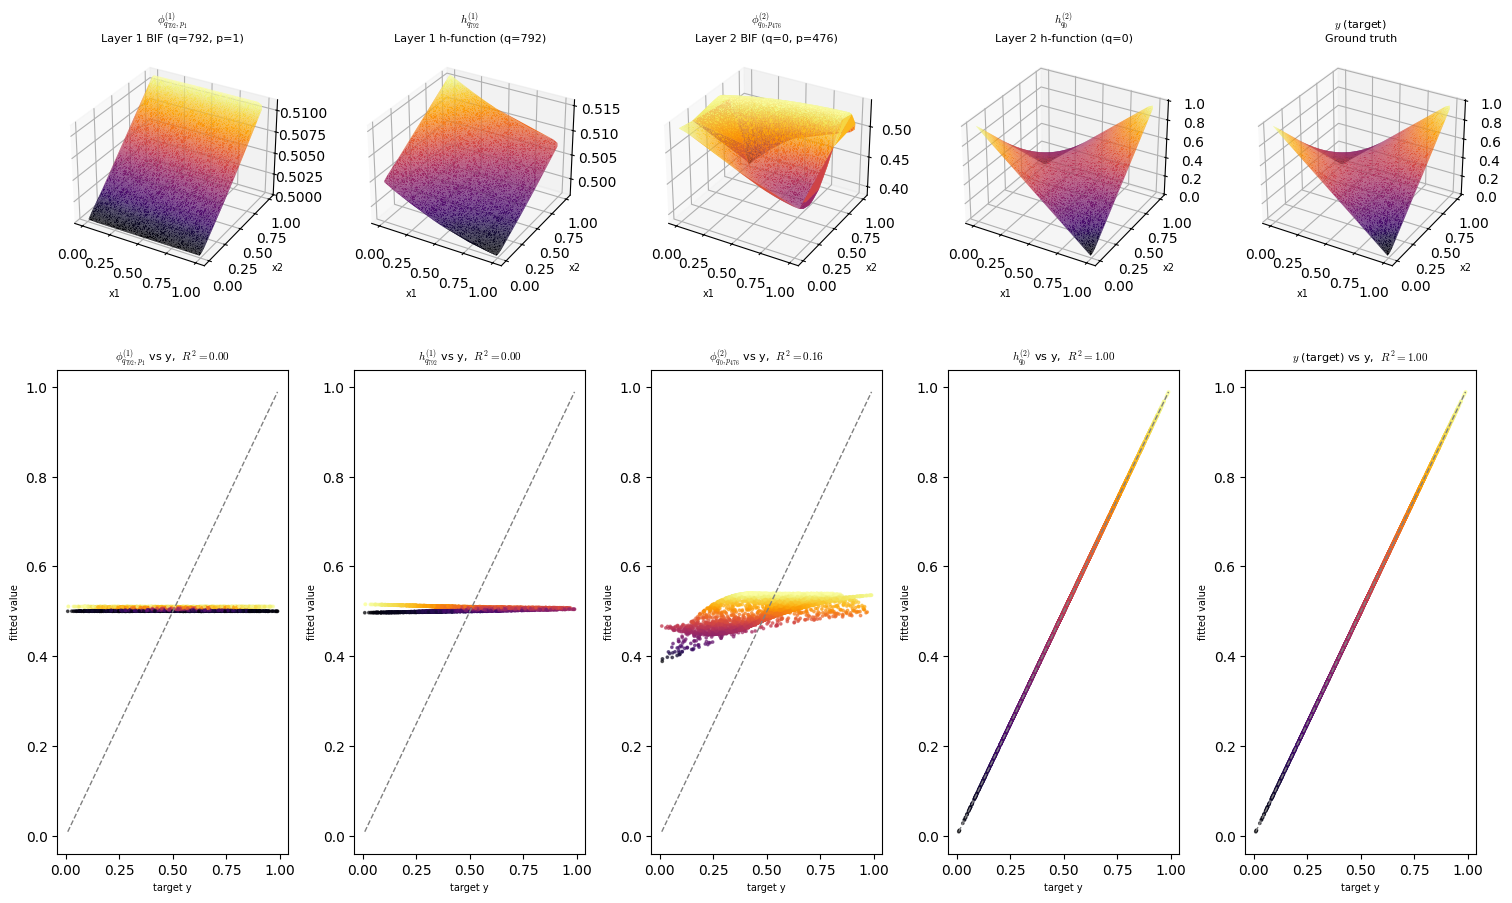

In [8]:
plot_hkan_stages_dynamic(tf1_x_train, tf1_y_train, tf1_stages, block_idx="random", seed=0)

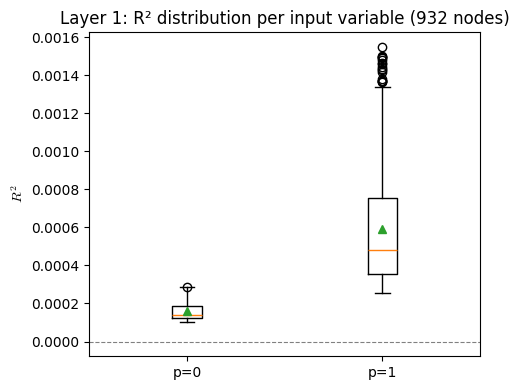

In [9]:
plot_first_layer_blf_r2_summary(tf1_stages, tf1_y_train)

### Edge Isolated SWIM

In [15]:
# edit this per run - centers/basis/layer count, whatever
tf1_layer_edge_swim_configs = [
    dict(n_vars_out=10, n_basis=2, centers="edge_isolated_swim_centers", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(n_vars_out=1, n_basis=13, centers="edge_isolated_swim_centers", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

tf1_edge_swim_stages, tf1_edge_swim_yhat = build_hkan_stack(tf1_x_train, tf1_y_train, tf1_layer_edge_swim_configs)
print("TF1 train R2:", r2_score(tf1_y_train, tf1_edge_swim_yhat))
print("TF1 train RMSE:", em.compute_rmse(tf1_edge_swim_yhat, tf1_y_train).item())

TF1 train R2: 0.9970726199999332
TF1 train RMSE: 0.008998934196112671


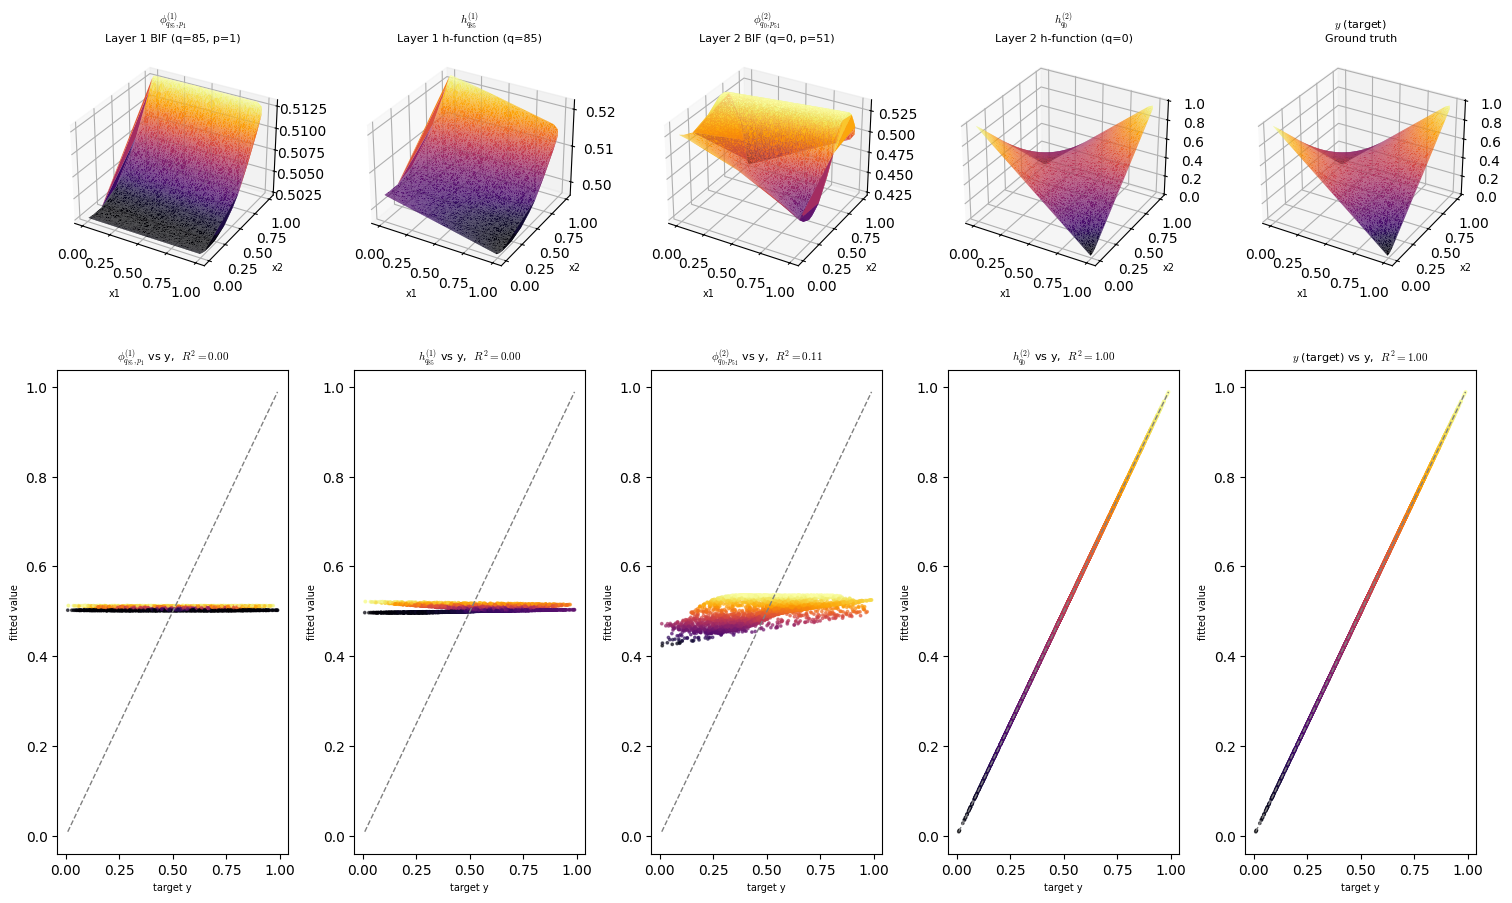

In [11]:
plot_hkan_stages_dynamic(tf1_x_train, tf1_y_train, tf1_edge_swim_stages, block_idx="random", seed=0)

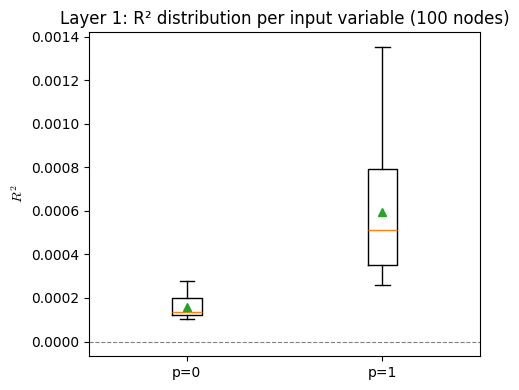

In [12]:
plot_first_layer_blf_r2_summary(tf1_edge_swim_stages, tf1_edge_swim_yhat)

## TF2

noisy one - has U(-0.2, 0.2) noise baked into the training data so don't expect R2 anywhere near 1, paper only got ~0.98 test RMSE reduction vs KAN not a perfect fit either. good one for checking that the h-functions are actually doing something over the raw phi blocks.


In [ ]:
tf2_trn = np.loadtxt(f"{DATA_DIR}/TF2_trn.csv", delimiter=",")
tf2_tst = np.loadtxt(f"{DATA_DIR}/TF2_tst.csv", delimiter=",")

tf2_x_train, tf2_y_train = tf2_trn[:, :-1], tf2_trn[:, -1]
tf2_x_test,  tf2_y_test  = tf2_tst[:, :-1], tf2_tst[:, -1]

print(tf2_x_train.shape, tf2_x_test.shape)


In [ ]:
tf2_layer_configs = [
    dict(n_vars_out=48, n_basis=17, centers="random", basis_fn=Tanh(s=22), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(n_vars_out=11, n_basis=21, centers="random_data_points", basis_fn=Softplus(s=18), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(n_vars_out=1, n_basis=10, centers="random", basis_fn=Identity(), expanding_base_regressor=Ridge()),
]

tf2_stages, tf2_yhat = build_hkan_stack(tf2_x_train, tf2_y_train, tf2_layer_configs)
print("TF2 train R2:", r2_score(tf2_y_train, tf2_yhat))


In [ ]:
plot_hkan_stages_dynamic(tf2_x_train, tf2_y_train, tf2_stages, block_idx="random", seed=0)

In [ ]:
plot_first_layer_blf_r2_summary(tf2_stages, tf2_y_train)

## TF3

periodic, big domain (x in [-500,500] before normalizing). no noise so should fit clean given enough basis functions. paper needed high m and big sigma for this one (see table IV, sigma=50), might need to push n_basis / sigma up here too if the fit looks flat.


In [ ]:
tf3_trn = np.loadtxt(f"{DATA_DIR}/TF3_trn.csv", delimiter=",")
tf3_tst = np.loadtxt(f"{DATA_DIR}/TF3_tst.csv", delimiter=",")

tf3_x_train, tf3_y_train = tf3_trn[:, :-1], tf3_trn[:, -1]
tf3_x_test,  tf3_y_test  = tf3_tst[:, :-1], tf3_tst[:, -1]

print(tf3_x_train.shape, tf3_x_test.shape)


In [ ]:
tf3_layer_configs = [
    dict(n_vars_out=924, n_basis=39, centers="random", basis_fn=Tanh(s=50)),
    dict(n_vars_out=1, n_basis=10, centers="random_data_points", basis_fn=Identity()),
]

tf3_stages, tf3_yhat = build_hkan_stack(tf3_x_train, tf3_y_train, tf3_layer_configs)
print("TF3 train R2:", r2_score(tf3_y_train, tf3_yhat))


In [ ]:
plot_hkan_stages_dynamic(tf3_x_train, tf3_y_train, tf3_stages, block_idx="random", seed=0)


In [ ]:
plot_first_layer_blf_r2_summary(tf3_stages, tf3_y_train)

## TF4

the odd one out - 10 inputs, radially symmetric function. plot function only does 2 axes at a time so picking 2 random input columns just to have something to look at, rest of the 8 dims are still used for fitting, just not shown on the surface plot. keeping the seed fixed so the same 2 columns get picked every time i rerun this cell.


In [ ]:
tf4_trn = np.loadtxt(f"{DATA_DIR}/TF4_trn.csv", delimiter=",")
tf4_tst = np.loadtxt(f"{DATA_DIR}/TF4_tst.csv", delimiter=",")

tf4_x_train, tf4_y_train = tf4_trn[:, :-1], tf4_trn[:, -1]
tf4_x_test,  tf4_y_test  = tf4_tst[:, :-1], tf4_tst[:, -1]

print(tf4_x_train.shape, tf4_x_test.shape)

# 10 inputs here, pick 2 at random just for plotting later
tf4_feature_idx = tuple(np.random.default_rng(1).choice(tf4_x_train.shape[1], size=2, replace=False))
print("using columns", tf4_feature_idx, "for the surface plots")


In [ ]:
tf4_layer_configs = [
    dict(n_vars_out=1, n_basis=2, centers="equally_spaced", basis_fn=Tanh(s=3)),
]

tf4_stages, tf4_yhat = build_hkan_stack(tf4_x_train, tf4_y_train, tf4_layer_configs)
print("TF4 train R2:", r2_score(tf4_y_train, tf4_yhat))


In [ ]:
plot_hkan_stages_dynamic(tf4_x_train, tf4_y_train, tf4_stages, block_idx="random", seed=0,
                          feature_idx=tf4_feature_idx)


In [ ]:
plot_first_layer_blf_r2_summary(tf4_stages, tf4_y_train)

## TF5

using the 2-arg version here (not TF5-5), plateaus with grooves, peaks where the grooves cross. no noise like TF3, should be able to get a tight fit with 2 layers if centers/sigma are reasonable.


In [ ]:
tf5_trn = np.loadtxt(f"{DATA_DIR}/TF5_trn.csv", delimiter=",")
tf5_tst = np.loadtxt(f"{DATA_DIR}/TF5_tst.csv", delimiter=",")

tf5_x_train, tf5_y_train = tf5_trn[:, :-1], tf5_trn[:, -1]
tf5_x_test,  tf5_y_test  = tf5_tst[:, :-1], tf5_tst[:, -1]

print(tf5_x_train.shape, tf5_x_test.shape)


In [ ]:
tf5_layer_configs = [
    dict(n_vars_out=912, n_basis=23, centers="random", basis_fn=Tanh(s=50)),
    dict(n_vars_out=1, n_basis=10, centers="random_data_points", basis_fn=Identity()),
]

tf5_stages, tf5_yhat = build_hkan_stack(tf5_x_train, tf5_y_train, tf5_layer_configs)
print("TF5 train R2:", r2_score(tf5_y_train, tf5_yhat))


In [ ]:
plot_hkan_stages_dynamic(tf5_x_train, tf5_y_train, tf5_stages, block_idx="random", seed=0)


In [ ]:
plot_first_layer_blf_r2_summary(tf5_stages, tf5_y_train)